# Social Network Extraction & Analysis

Demo of the `SocialNetworkTask` and `analysis.social_networks` module.

Three novels compared:
- **Haywood, *The Masqueraders*** (1725) — short amatory fiction, 3 characters
- **Defoe, *Moll Flanders*** (1722) — picaresque, 46 characters, 38 locations
- **Austen, *Emma*** (1816) — domestic novel, 36 characters, 22 locations

In [42]:
import json
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from largeliterarymodels.analysis.social_networks import *
plt.rcParams['figure.dpi'] = 300

## 1. Load results

In [35]:
emma = load_result('../data/social_network_chadwyck_Nineteenth-Century_Fiction_ncf0204.01_qwen36-27b.json')
moll = load_result('../data/social_network_chadwyck_Eighteenth-Century_Fiction_defoe.06_qwen36-27b.json')
# haywood = load_result('../data/social_network_chadwyck_Eighteenth-Century_Fiction_haywood.13_qwen36-27b.json')

novels = {'Emma': emma, 'Moll Flanders': moll}

for title, result in novels.items():
    m = result.get('metadata', {})
    print(f"{title}: {len(result['characters'])} chars, {len(result['relations'])} rels, "
          f"{len(result['events'])} events, {len(result['dialogue'])} dialogue, "
          f"{m.get('n_passages', '?')} passages")

Emma: 36 chars, 115 rels, 143 events, 107 dialogue, 313 passages
Moll Flanders: 46 chars, 90 rels, 144 events, 80 dialogue, 238 passages


## 2. Character registers

In [36]:
for title, result in novels.items():
    print(f'\n=== {title} ({len(result["characters"])} characters) ===')
    for c in sorted(result['characters'], key=lambda x: int(x['id'][1:])):
        aliases = f" / {', '.join(c['aliases'])}" if c.get('aliases') else ''
        print(f"  {c['id']:5s} {c['name'][:35]:35s} {c['gender']:8s} {c['class']}{aliases}")


=== Emma (36 characters) ===
  C01   Emma Woodhouse                      female   gentry
  C02   Mr. Woodhouse                       male     gentry
  C03   Miss Taylor                         female   gentry
  C04   Mr. Weston                          male     gentry
  C05   Isabella                            female   gentry
  C06   Mr. Knightley                       male     gentry
  C07   James                               male     servant
  C08   Hannah                              female   servant
  C09   Mr. Elton                           male     clergy
  C10   Mrs. Churchill                      female   aristocracy
  C11   Mr. Churchill                       male     aristocracy
  C12   Mrs. Churchill                      female   aristocracy
  C13   Frank Churchill                     male     aristocracy
  C14   Mrs. Perry                          female   professional
  C15   Miss Bates                          female   clergy family
  C16   Mr. Perry                  

## 3. Social network graphs

In [40]:
emma_rel_graph = build_directed_graph(moll)
emma_event_graph = build_event_graph(emma)
emma_speech_graph = build_dialogue_graph(emma)

for a,b,d in emma_rel_graph.edges(data=True):
    print(f'{emma_rel_graph.nodes[a]["name"]} {d.get("type").upper()} {emma_rel_graph.nodes[b]["name"]}')

emma_event_graph.edges(data=True)
# emma_speech_graph.edges(data=True)

Moll Flanders CHILD_OF Moll's Mother
Moll Flanders ATTRACTED_TO The Elder Brother
Moll Flanders REJECTED The Younger Brother
Moll Flanders SPOUSE_OF The Gentleman-Draper
Moll Flanders FRIEND_OF The Linen-Draper
Moll Flanders FRIEND_OF The Widow Captain's Wife
Moll Flanders CONFIDANTE_OF The Young Lady
Moll Flanders FRIEND_OF The Captain's Wife
Moll Flanders SPOUSE_OF Moll's Second Husband
Moll Flanders SERVED_BY The Bath Landlady
Moll Flanders SPOUSE_OF The Gentleman
Moll Flanders ALLIED_WITH North Country Gentlewoman
Moll Flanders CONFIDANTE_OF Bank Clerk
Moll Flanders SPOUSE_OF The Irish Gentleman
Moll Flanders SERVED_BY Mrs. Brown (The Midwife)
Moll Flanders SPOUSE_OF The Banker
Moll Flanders CONFIDANTE_OF The Nurse
Moll Flanders ALLIED_WITH The Young Male Thief
Moll Flanders ALLIED_WITH The Lace Chamber Woman
Moll Flanders DECEIVED The Drunk Gentleman
Moll Flanders ENEMY_OF The Mercer
Moll Flanders EMPLOYED_BY The Attorney
Moll Flanders DECEIVED The Gentleman (Horse Owner)
Moll Fla

OutEdgeDataView([('C01', 'C18', {'weight': 10, 'events': ['befriended', 'painted', 'hosted', 'manipulated', 'manipulated', 'confessed to', 'shopped', 'advised', 'wrote', 'wrote']}), ('C01', 'C19', {'weight': 1, 'events': ['met']}), ('C01', 'C06', {'weight': 5, 'events': ['reconciled', 'debated', 'discussed', 'engaged', 'married']}), ('C01', 'C04', {'weight': 1, 'events': ['visited']}), ('C01', 'C09', {'weight': 2, 'events': ['rejected', 'visited']}), ('C01', 'C15', {'weight': 3, 'events': ['visited', 'insulted', 'visited']}), ('C01', 'C22', {'weight': 2, 'events': ['visited', 'visited']}), ('C01', 'C28', {'weight': 1, 'events': ['attended dinner']}), ('C01', 'C13', {'weight': 2, 'events': ['traveled', 'flirted']}), ('C01', 'C03', {'weight': 1, 'events': ['visited']}), ('C03', 'C04', {'weight': 1, 'events': ['married']}), ('C03', 'C22', {'weight': 1, 'events': ['visited']}), ('C05', 'C06', {'weight': 1, 'events': ['arrived']}), ('C06', 'C01', {'weight': 6, 'events': ['discussed', 'confr

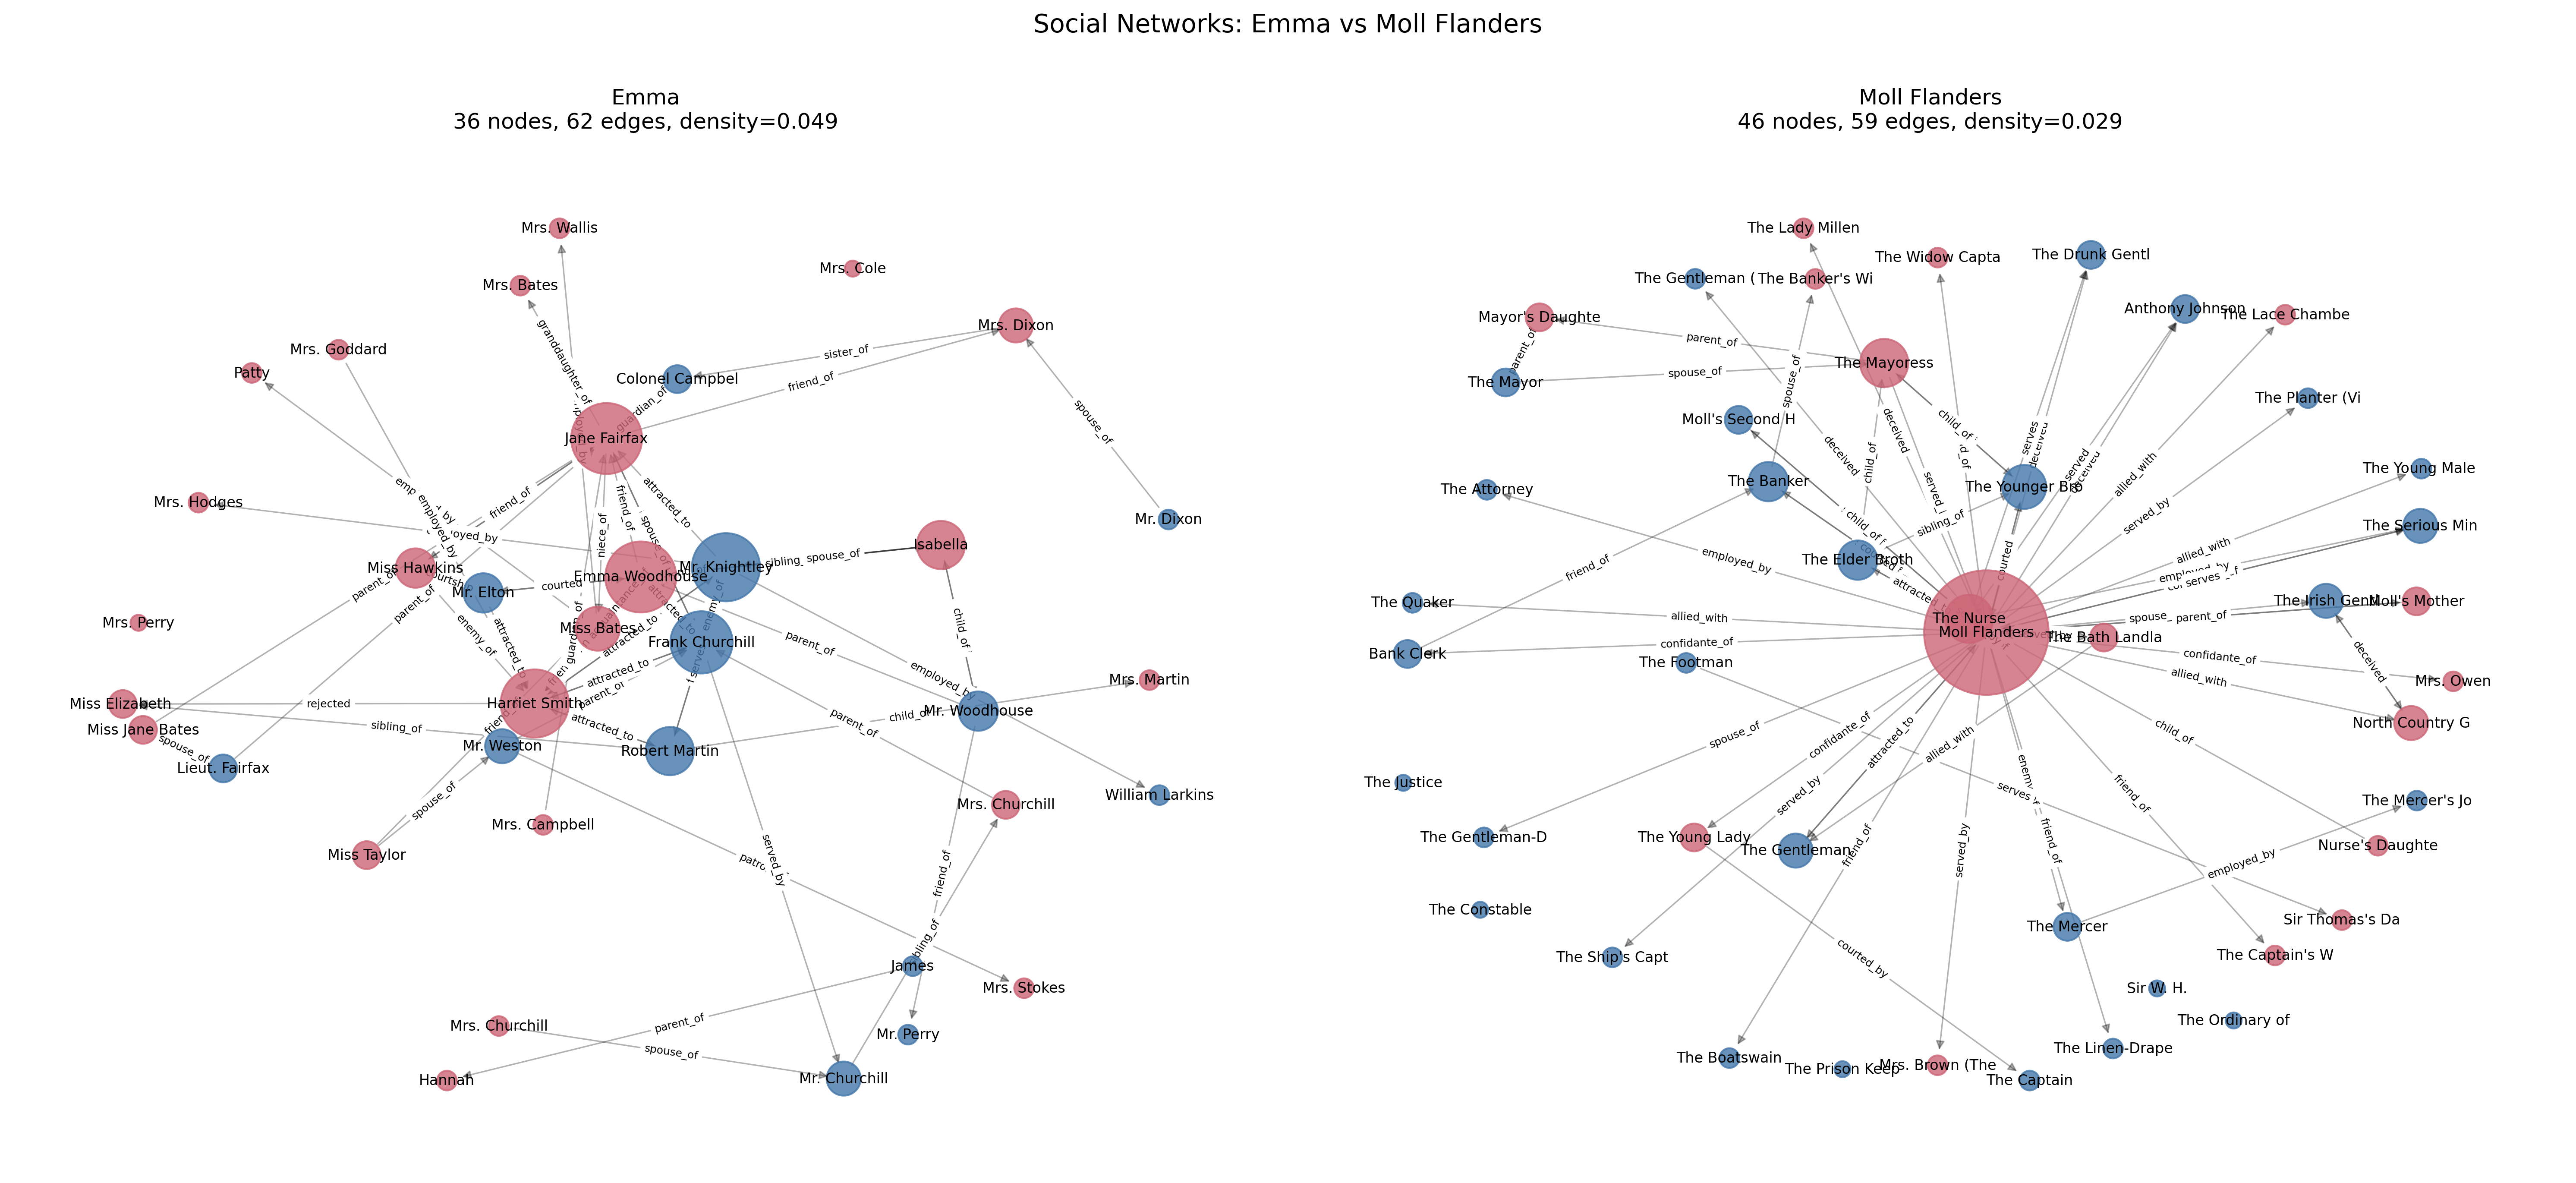

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, (title, result) in zip(axes, novels.items()):
    G = build_directed_graph(result)
    pos = nx.spring_layout(G, seed=42, k=0.9)

    color_map = {'male': '#4477AA', 'female': '#CC6677', 'unknown': '#999999'}
    colors = [color_map.get(G.nodes[n].get('gender', ''), '#999') for n in G.nodes()]
    degrees = dict(G.degree())
    sizes = [max(80, degrees.get(n, 1) * 120) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes, alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=0.8)
    labels = {n: G.nodes[n].get('name', n)[:15] for n in G.nodes()}
    edge_labels = {(a,b): d.get('type') for a,b,d in G.edges(data=True)}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8)
    nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax, font_size=6)

    m = network_metrics(G)
    ax.set_title(f"{title}\n{m['n_nodes']} nodes, {m['n_edges']} edges, "
                 f"density={m['density']:.3f}", fontsize=12)
    ax.axis('off')

plt.suptitle('Social Networks: Emma vs Moll Flanders', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/moll-vs-emma.png')
plt.show()

## 4. Network metrics comparison

In [5]:
rows = []
for title, result in novels.items():
    G = build_graph(result)
    m = network_metrics(G)
    m['novel'] = title
    m['n_locations'] = len(set(e['where'] for e in result['events'] if e.get('where')))
    m['n_dialogue'] = len(result['dialogue'])
    m['max_degree_name'] = G.nodes[m['max_degree_node']].get('name', '?') if 'max_degree_node' in m else '?'
    rows.append(m)

metrics_df = pd.DataFrame(rows).set_index('novel')
display_cols = ['n_nodes', 'n_edges', 'density', 'mean_degree', 'clustering',
                'diameter', 'avg_path_length', 'max_degree_name', 'max_degree',
                'n_locations', 'n_dialogue']
metrics_df[[c for c in display_cols if c in metrics_df.columns]]

,n_nodes,n_edges,density,mean_degree,clustering,diameter,avg_path_length,max_degree_name,max_degree,n_locations,n_dialogue
novel,,,,,,,,,,,
Emma,36,50,0.079365,2.777778,0.259578,5,2.782258,Jane Fairfax,11,22,107
Moll Flanders,46,49,0.047343,2.130435,0.283728,4,2.213225,Moll Flanders,32,38,80


## 5. Relation types

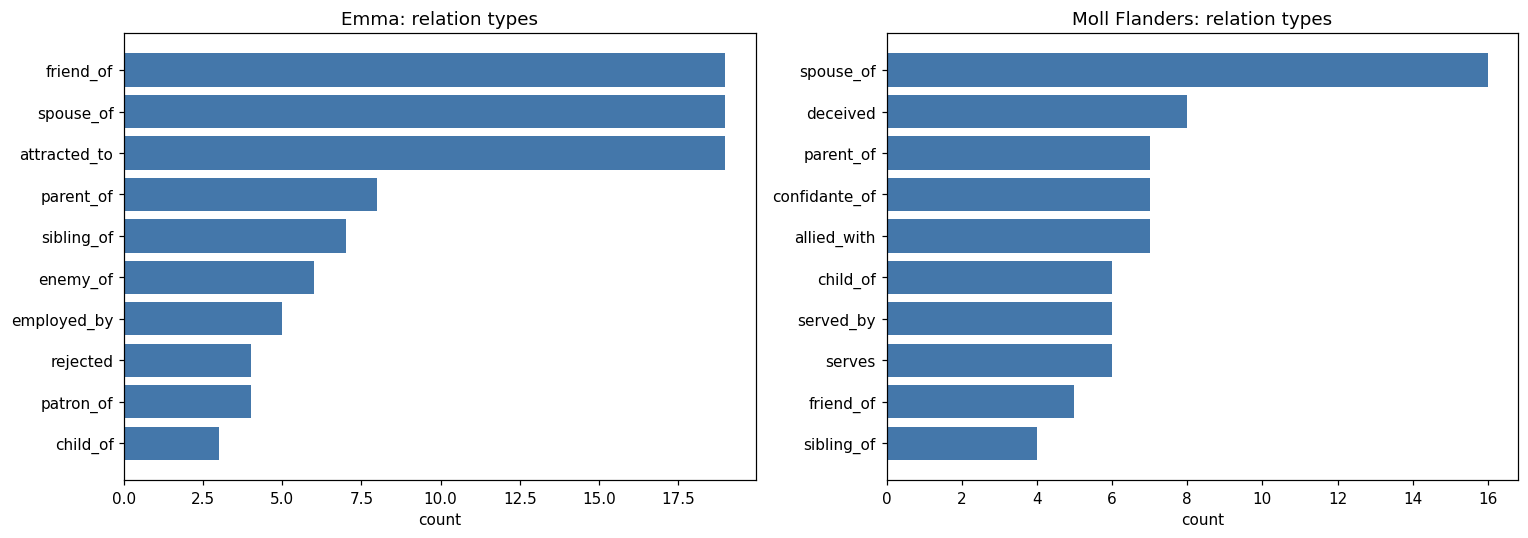

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, result) in zip(axes, novels.items()):
    counts = relation_type_counts(result)
    del counts['same_as']  # identity, not social
    top = counts.most_common(10)
    ax.barh([t for t, _ in reversed(top)], [n for _, n in reversed(top)], color='#4477AA')
    ax.set_title(f'{title}: relation types')
    ax.set_xlabel('count')

plt.tight_layout()
plt.show()

## 6. Event verbs

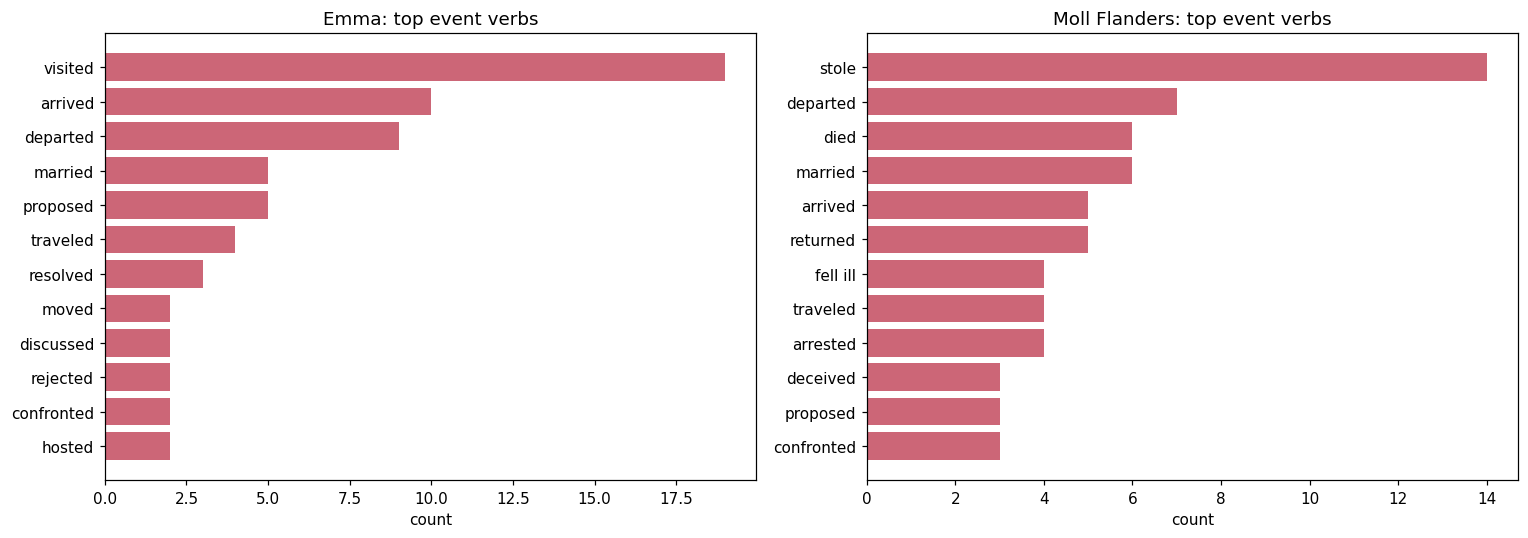

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, result) in zip(axes, novels.items()):
    counts = event_verb_counts(result)
    top = counts.most_common(12)
    ax.barh([t for t, _ in reversed(top)], [n for _, n in reversed(top)], color='#CC6677')
    ax.set_title(f'{title}: top event verbs')
    ax.set_xlabel('count')

plt.tight_layout()
plt.show()

## 7. Dialogue networks

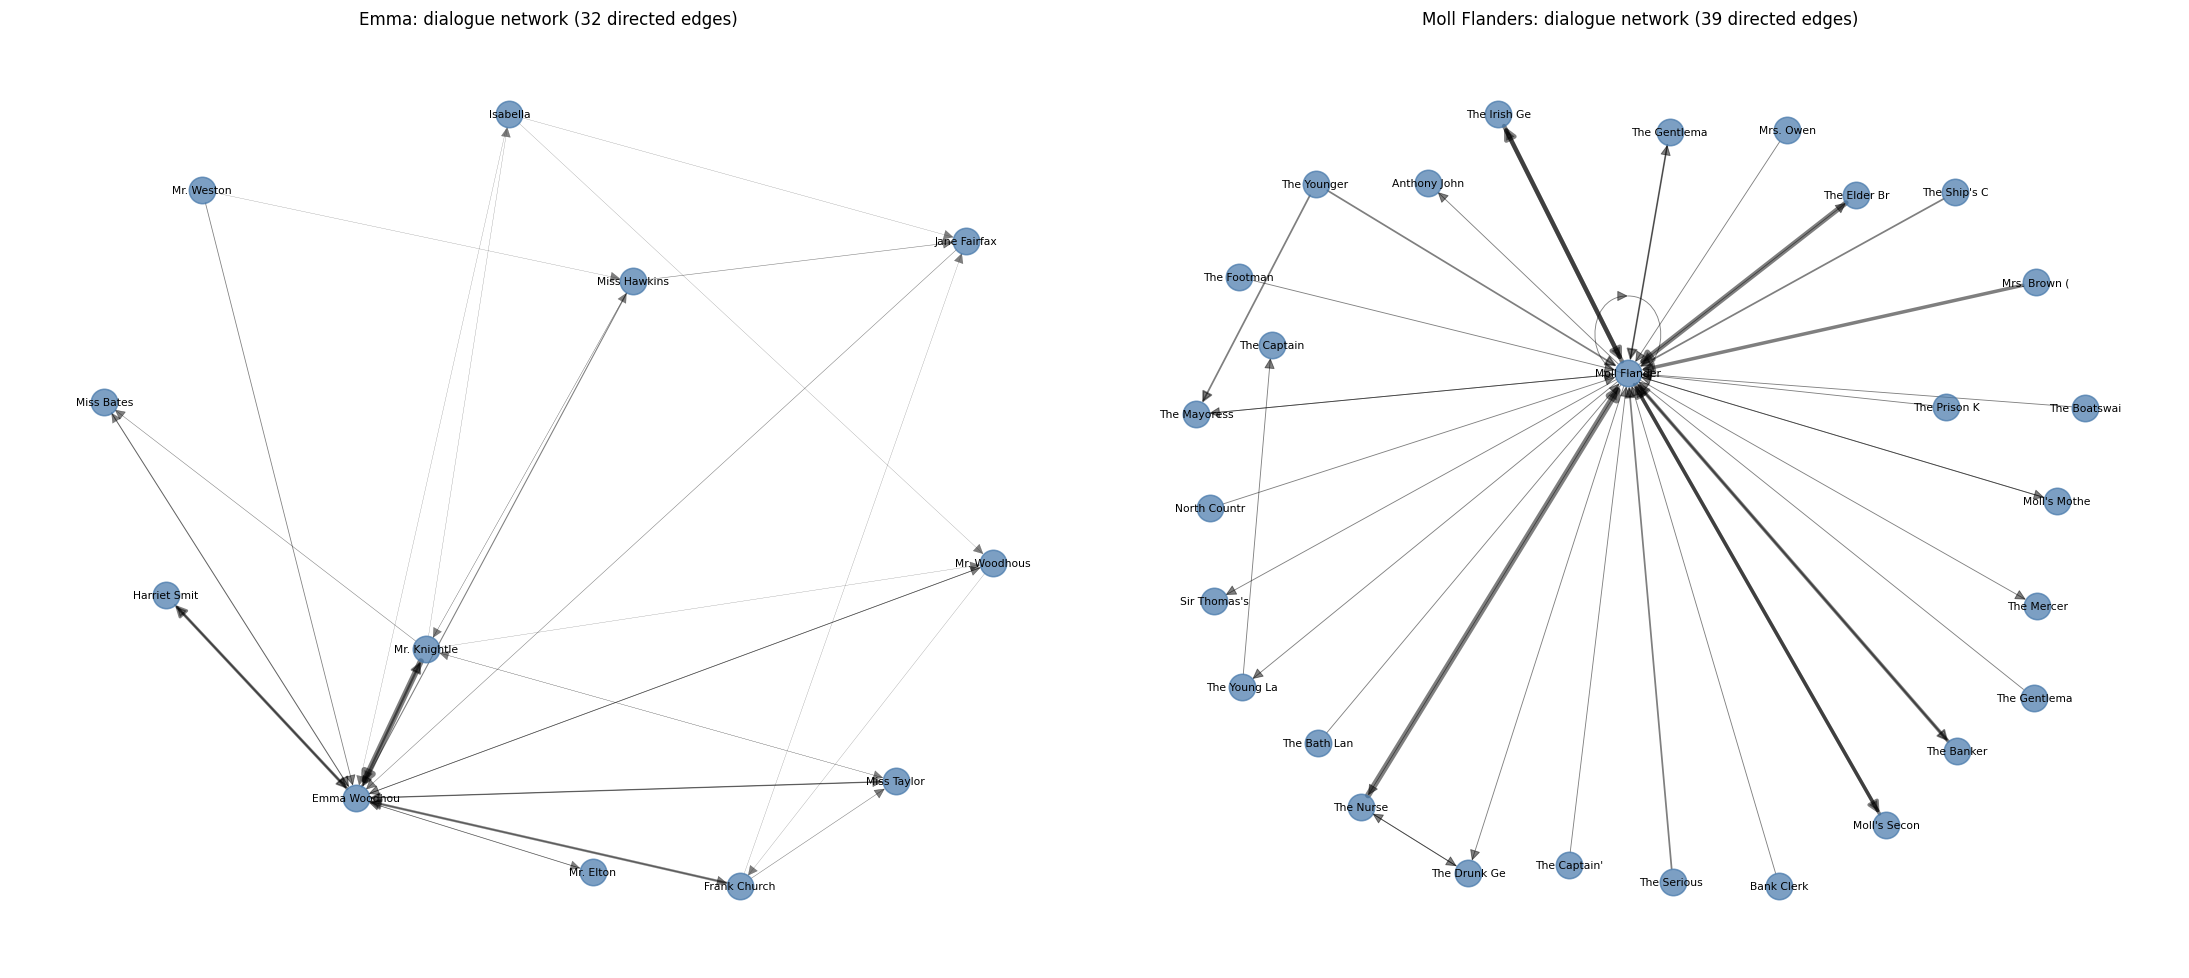

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, (title, result) in zip(axes, novels.items()):
    DG = build_dialogue_graph(result)
    # Only show nodes involved in dialogue
    active = [n for n in DG.nodes() if DG.degree(n) > 0]
    DG = DG.subgraph(active)

    pos = nx.spring_layout(DG, seed=42, k=2.5)
    weights = [DG[u][v]['weight'] for u, v in DG.edges()]
    max_w = max(weights) if weights else 1

    nx.draw_networkx_nodes(DG, pos, ax=ax, node_size=300, node_color='#4477AA', alpha=0.7)
    nx.draw_networkx_edges(DG, pos, ax=ax, width=[w / max_w * 4 for w in weights],
                           alpha=0.5, arrows=True, arrowsize=15)
    labels = {n: DG.nodes[n].get('name', n)[:12] for n in DG.nodes()}
    nx.draw_networkx_labels(DG, pos, labels, ax=ax, font_size=7)

    ax.set_title(f'{title}: dialogue network ({DG.number_of_edges()} directed edges)', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Location analysis

In [9]:
for title, result in novels.items():
    locs = location_summary(result)
    print(f'\n=== {title}: {len(locs)} locations ===')
    print(locs[['n_events', 'n_characters', 'first_passage', 'last_passage']].head(12).to_string())


=== Emma: 22 locations ===
                       n_events  n_characters first_passage last_passage
location                                                                
Hartfield                    40             7          P003         P301
Randalls                     16             8          P000         P307
Highbury                     16             9          P000         P312
Donwell Abbey                 6             6          P224         P294
London                        5             3          P008         P303
Crown Inn                     5             4          P159         P207
Miss Bates's house            4             2          P147         P154
Miss Bates's home             3             3          P267         P292
Cole's house                  3             3          P143         P144
Mr. Cole's house              3             2          P130         P139
Box Hill                      3             2          P234         P239
Mrs. Goddard's school  

## 9. Character trajectories

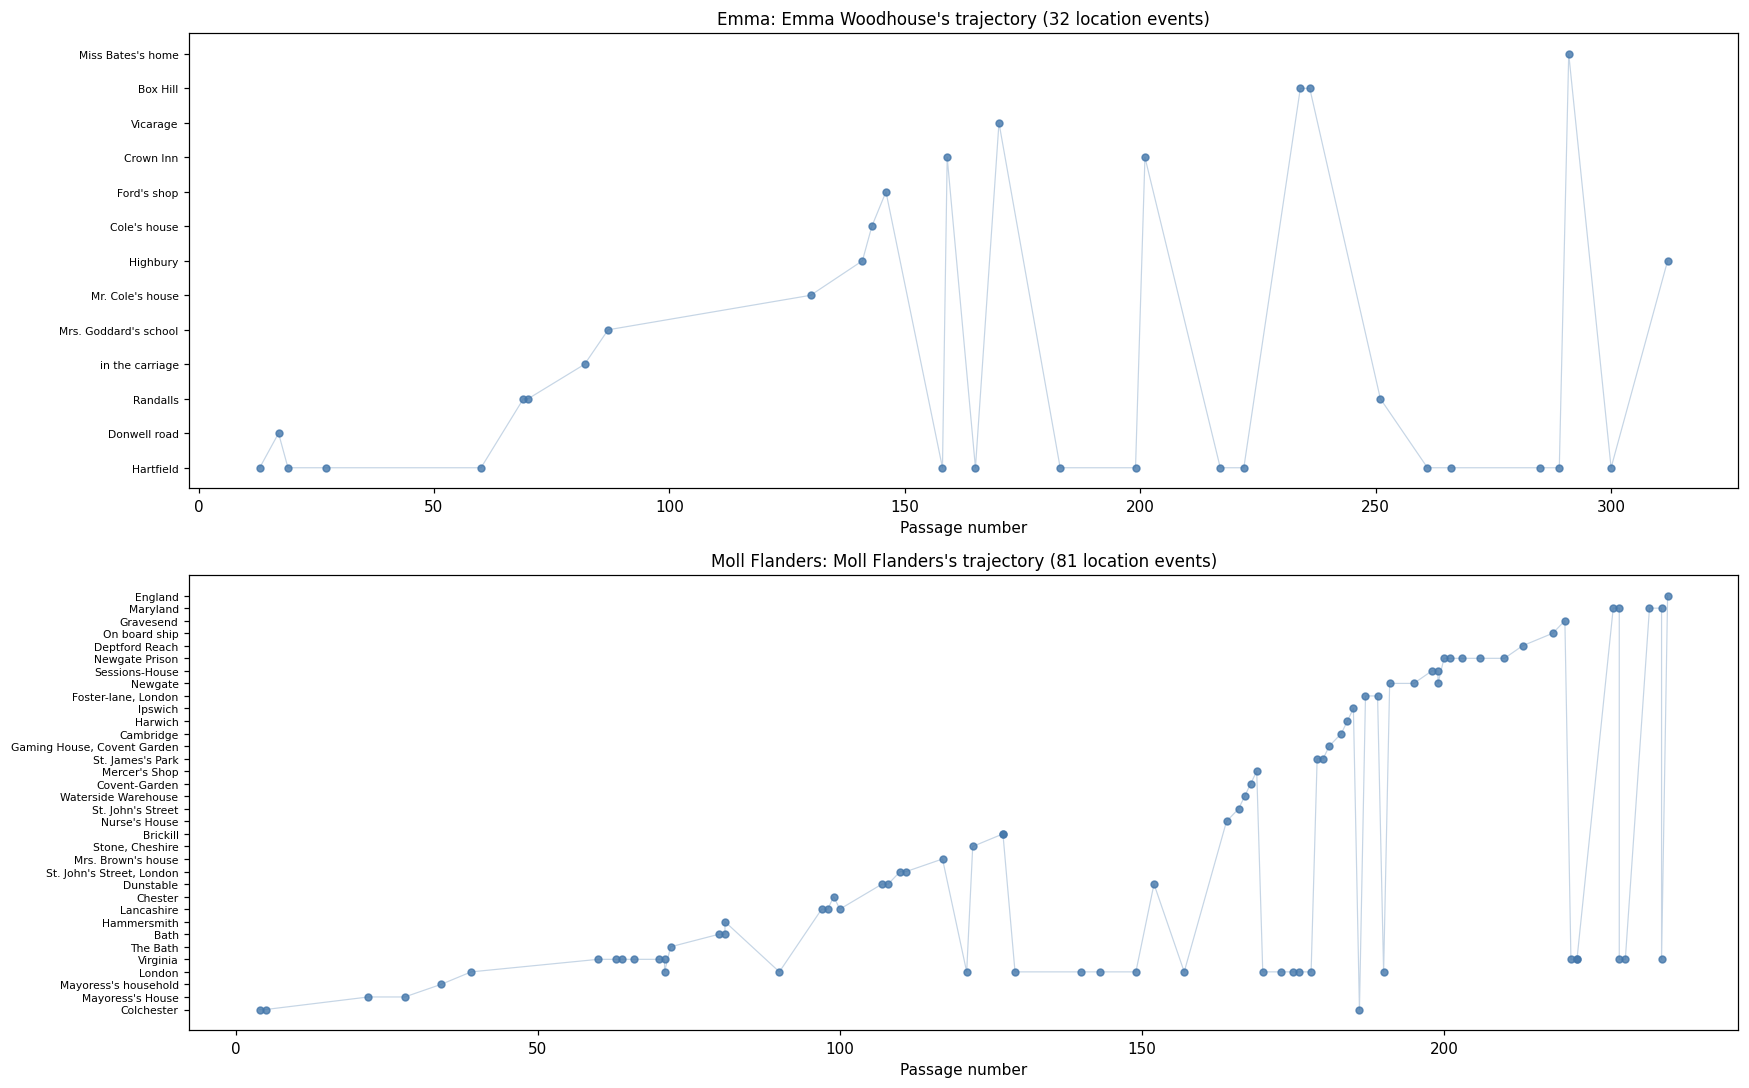

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, (title, result), protagonist in zip(axes, novels.items(), ['C01', 'C01']):
    trajs = character_trajectories(result)
    traj = trajs.get(protagonist, [])
    if not traj:
        continue

    # Extract passage numbers and locations
    passages = [int(t['passage'][1:]) for t in traj if t['passage'].startswith('P')]
    locations = [t['where'] for t in traj if t['passage'].startswith('P')]

    # Assign y-axis positions to unique locations (order of first appearance)
    seen = {}
    for loc in locations:
        if loc not in seen:
            seen[loc] = len(seen)
    y = [seen[loc] for loc in locations]

    ax.scatter(passages, y, s=20, alpha=0.8, c='#4477AA')
    ax.plot(passages, y, alpha=0.3, c='#4477AA', linewidth=0.8)
    ax.set_yticks(list(seen.values()))
    ax.set_yticklabels(list(seen.keys()), fontsize=7)
    ax.set_xlabel('Passage number')

    char_name = next((c['name'] for c in result['characters'] if c['id'] == protagonist), protagonist)
    ax.set_title(f"{title}: {char_name}'s trajectory ({len(traj)} location events)", fontsize=11)

plt.tight_layout()
plt.show()

## 10. Story chain (narrative summaries)

In [11]:
for title, result in novels.items():
    print(f'\n{"=" * 70}')
    print(f'{title} — {len(result["summaries"])} chunk summaries')
    print(f'{"=" * 70}')
    for s in result['summaries']:
        print(f"\n[P{s['start']:03d}-P{s['end']:03d}]")
        print(f"  {s['text']}")


Emma — 32 chunk summaries

[P000-P009]
  Emma Woodhouse (C01) mourns the marriage of her governess and friend Miss Taylor (C03) to Mr. Weston (C04), who has moved to Randalls. Her father, Mr. Woodhouse (C02), is distressed by the change. Mr. Knightley (C06), a close family friend, visits and critiques Emma’s pride in having orchestrated the match. Emma resolves to find a wife for the local vicar, Mr. Elton (C09). Background is provided on Mr. Weston’s past marriage to Mrs. Churchill (C10) and his son Frank (C13), who is raised by his wealthy uncle Mr. Churchill (C11) and aunt Mrs. Churchill (C12). Frank writes to his stepmother. The community, including the Bates family (C15) and apothecary Mr. Perry (C16), reacts to the wedding.

[P010-P019]
  Emma (C01) hosts Mrs. Goddard (C17), Miss Bates (C15), and Mrs. Bates (C15's mother) at Hartfield. Mrs. Goddard brings Harriet Smith (C18), an illegitimate student, whom Emma immediately decides to patronize and improve. Emma learns Harriet has

## 11. Running the task

```python
from largeliterarymodels.tasks import SocialNetworkTask

task = SocialNetworkTask(model='lmstudio/qwen/qwen3.6-27b')

# From lltk text ID
result = task.run('_chadwyck/Eighteenth-Century_Fiction/defoe.06', save=True)

# From a plain text file
result = task.run('/path/to/novel.txt', save=True)

# From a list of passage strings
result = task.run(['passage 1 text...', 'passage 2 text...'], save=True)

# With Sonnet (~$1.20/novel, higher quality)
task = SocialNetworkTask(model='claude-sonnet-4-6')
result = task.run('_chadwyck/Eighteenth-Century_Fiction/defoe.06', save=True)
```